In [1]:
!pip install xgboost
!pip install imbalanced-learn
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       756
           1       0.91      0.84      0.87       145

    accuracy                           0.96       901
   macro avg       0.94      0.91      0.93       901
weighted avg       0.96      0.96      0.96       901

Accuracy: 0.9611542730299667
Precision: 0.9104477611940298
Recall: 0.8413793103448276
F1-score: 0.8745519713261649
AUC-ROC: 0.9582101806239738


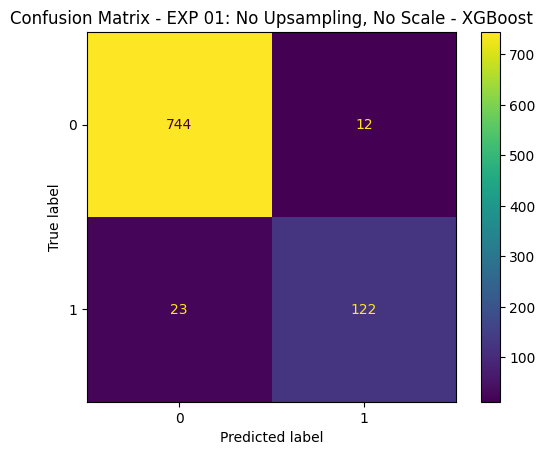

In [3]:
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

# Đọc dữ liệu đã clean
dataset = pd.read_csv("cleaned_data.csv")

# Tách X và y
X = dataset.drop(["CustomerID", "Churn"], axis=1)
y = dataset["Churn"]

# Chia train, test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# XGBoost model
model_xgb = xgb.XGBClassifier(
    random_state=42,
    n_estimators=200,
    eval_metric="logloss"
)

# Train model
model_xgb.fit(X_train, y_train)

# Predict
y_pred = model_xgb.predict(X_test)

# Predict probability để tính AUC-ROC
y_proba = model_xgb.predict_proba(X_test)[:, 1]

# Classification report
print(classification_report(y_test, y_pred))

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_proba)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("AUC-ROC:", auc_roc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_xgb.classes_
)

disp.plot()
plt.title("Confusion Matrix - EXP 01: No Upsampling, No Scale - XGBoost")
plt.show()


              precision    recall  f1-score   support

           0       0.92      0.95      0.93       756
           1       0.68      0.54      0.61       145

    accuracy                           0.89       901
   macro avg       0.80      0.75      0.77       901
weighted avg       0.88      0.89      0.88       901

Accuracy: 0.8856825749167592
Precision: 0.6810344827586207
Recall: 0.5448275862068965
F1-score: 0.6053639846743295
AUC-ROC: 0.8817186644772852


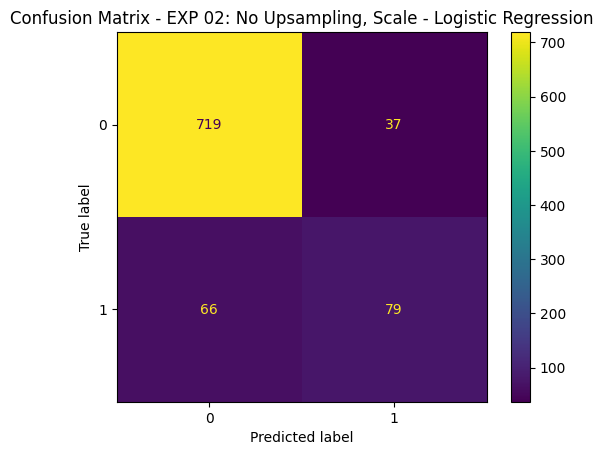

In [4]:
# EXP 02: Không Upsampling, Có Scale — Model: Logistic Regression
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

# Đọc dữ liệu đã clean
dataset = pd.read_csv("cleaned_data.csv")

# Tách X và y
X = dataset.drop(["CustomerID", "Churn"], axis=1, errors="ignore")
y = dataset["Churn"]

# Chia train, test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale dữ liệu
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
model_lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train model
model_lr.fit(X_train_scaled, y_train)

# Predict
y_pred = model_lr.predict(X_test_scaled)

# Predict probability để tính AUC-ROC
y_proba = model_lr.predict_proba(X_test_scaled)[:, 1]

# Classification report
print(classification_report(y_test, y_pred))

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_proba)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("AUC-ROC:", auc_roc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_lr.classes_
)

disp.plot()
plt.title("Confusion Matrix - EXP 02: No Upsampling, Scale - Logistic Regression")
plt.show()

Trước SMOTE:
Churn
0    2990
1     613
Name: count, dtype: int64

Sau SMOTE:
Churn
0    2990
1    2990
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       756
           1       0.66      0.72      0.69       145

    accuracy                           0.89       901
   macro avg       0.80      0.83      0.81       901
weighted avg       0.90      0.89      0.90       901

Accuracy: 0.8945615982241953
Precision: 0.65625
Recall: 0.7241379310344828
F1-score: 0.6885245901639344
AUC-ROC: 0.9120324758255793


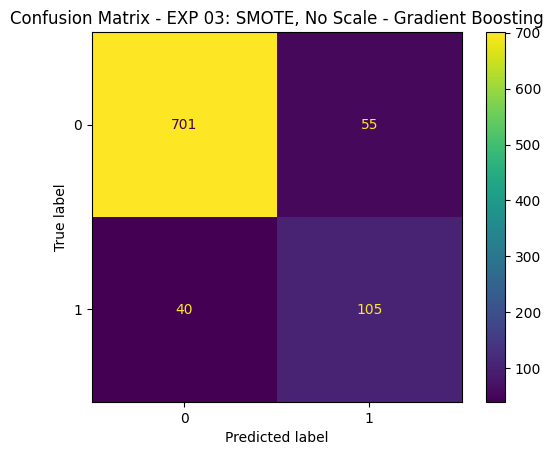

In [5]:
# EXP 03: Upsampling bằng SMOTE, Không Scale — Model: Gradient Boosting
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE

# Đọc dữ liệu đã clean
dataset = pd.read_csv("cleaned_data.csv")

# Tách X và y
X = dataset.drop(["CustomerID", "Churn"], axis=1, errors="ignore")
y = dataset["Churn"]

# Chia train, test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Upsampling bằng SMOTE
sm = SMOTE(
    k_neighbors=5,
    random_state=42
)

X_train_resample, y_train_resample = sm.fit_resample(X_train, y_train)

# Kiểm tra số lượng trước và sau SMOTE
print("Trước SMOTE:")
print(y_train.value_counts())

print("\nSau SMOTE:")
print(y_train_resample.value_counts())

# Gradient Boosting model
model_gb = GradientBoostingClassifier(
    random_state=42
)

# Train model bằng dữ liệu đã SMOTE
model_gb.fit(X_train_resample, y_train_resample)

# Predict trên tập test gốc
y_pred = model_gb.predict(X_test)

# Predict probability để tính AUC-ROC
y_proba = model_gb.predict_proba(X_test)[:, 1]

# Classification report
print(classification_report(y_test, y_pred))

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_proba)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("AUC-ROC:", auc_roc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_gb.classes_
)

disp.plot()
plt.title("Confusion Matrix - EXP 03: SMOTE, No Scale - Gradient Boosting")
plt.show()


Trước SMOTE:
Churn
0    2990
1     613
Name: count, dtype: int64

Sau SMOTE:
Churn
0    2990
1    2990
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       756
           1       0.86      0.77      0.81       145

    accuracy                           0.94       901
   macro avg       0.91      0.87      0.89       901
weighted avg       0.94      0.94      0.94       901

Accuracy: 0.9433962264150944
Precision: 0.8615384615384616
Recall: 0.7724137931034483
F1-score: 0.8145454545454546
AUC-ROC: 0.9777640941434044


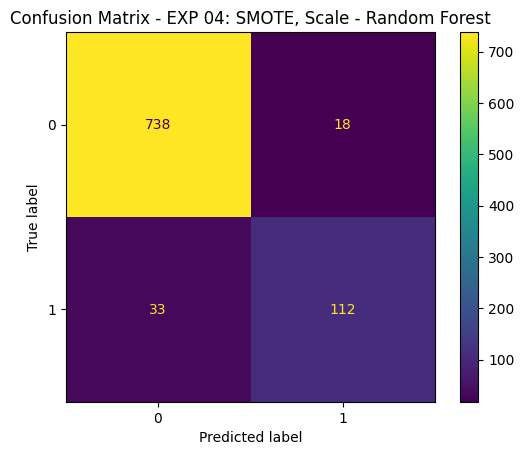

In [6]:
# Exp 04: Up Sampling, Scale, model : RFC
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE

# Đọc dữ liệu đã clean
dataset = pd.read_csv("cleaned_data.csv")

# Tách X và y
X = dataset.drop(["CustomerID", "Churn"], axis=1, errors="ignore")
y = dataset["Churn"]

# Chia train, test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale dữ liệu
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Upsampling bằng SMOTE
sm = SMOTE(
    k_neighbors=5,
    random_state=42
)

X_train_resample, y_train_resample = sm.fit_resample(
    X_train_scaled,
    y_train
)

# Kiểm tra số lượng trước và sau SMOTE
print("Trước SMOTE:")
print(y_train.value_counts())

print("\nSau SMOTE:")
print(y_train_resample.value_counts())

# Random Forest Classifier model
model_rfc = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)

# Train model bằng dữ liệu đã scale và SMOTE
model_rfc.fit(X_train_resample, y_train_resample)

# Predict trên tập test đã scale
y_pred = model_rfc.predict(X_test_scaled)

# Predict probability để tính AUC-ROC
y_proba = model_rfc.predict_proba(X_test_scaled)[:, 1]

# Classification report
print(classification_report(y_test, y_pred))

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_proba)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("AUC-ROC:", auc_roc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_rfc.classes_
)

disp.plot()
plt.title("Confusion Matrix - EXP 04: SMOTE, Scale - Random Forest")
plt.show()